## Bayesian Tracker for the Adaptive AI study platform -  

### Setup -

In [ ]:
! pip install torch matplotlib -q
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


#### 1. `Using device: cpu`

This tells us **where the model is running**.

- If it says `cpu`, our Colab session does not have a GPU.
- If it says `cuda`, the model is running on a GPU.

This affects speed, not correctness.


### Simuating Student Topic Interaction Data

In [ ]:
NUM_USERS = 50
NUM_TOPICS = 20
SEQ_LEN_MIN = 30
SEQ_LEN_MAX = 80

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Ground truth per topic difficulty level (higher = harder)
true_topic_difficulty = np.random.uniform(0.2, 0.8, size=NUM_TOPICS)

# Ground truth per user ability
true_user_ability = np.random.uniform(0.2, 0.8, size=NUM_USERS)

def simulate_interaction(user_id, topic_id):
    """
    Simulate whether a user answers a topic correctly.
    P(correct) = sigmoid(ability - difficulty) + some noise
    """
    ability = true_user_ability[user_id]
    difficulty = true_topic_difficulty[topic_id]
    logit = ability - difficulty
    p_correct = 1 / (1 + math.exp(-3 * logit))  # steeper sigmoid
    p_correct = max(0.05, min(0.95, p_correct))
    return 1 if random.random() < p_correct else 0

# Building sequences: list of (user_id, [(topic_idx, correct), ...])
user_sequences = []
for user_id in range(NUM_USERS):
    seq_len = random.randint(SEQ_LEN_MIN, SEQ_LEN_MAX)
    seq = []
    for _ in range(seq_len):
        topic_id = random.randint(0, NUM_TOPICS - 1)
        correct = simulate_interaction(user_id, topic_id)
        seq.append((topic_id, correct))
    user_sequences.append((user_id, seq))

print(f"Simulated {len(user_sequences)} users with sequences.")
print("Example:", user_sequences[0][:5])

Simulated 50 users with sequences.
Example: (0, [(3, 1), (8, 1), (4, 0), (17, 1), (13, 1), (2, 1), (16, 1), (17, 1), (17, 1), (14, 1), (0, 0), (5, 0), (10, 1), (6, 0), (10, 1), (12, 1), (11, 0), (1, 0), (17, 1), (12, 1), (9, 0), (19, 0), (11, 0), (2, 1), (7, 0), (2, 0), (3, 1), (14, 1), (11, 1), (11, 1), (8, 0), (2, 0), (5, 1), (7, 1), (12, 1), (17, 1), (10, 0), (1, 1), (1, 0), (12, 1), (6, 0), (18, 0), (10, 1), (15, 1), (14, 1), (4, 1), (17, 1), (18, 1), (18, 1), (7, 0), (4, 1), (2, 0), (3, 1), (5, 0), (13, 1), (12, 1), (14, 1), (17, 0), (0, 0), (3, 0), (17, 0), (10, 1), (13, 1), (0, 0), (8, 0), (5, 1), (3, 0), (9, 0), (16, 1), (4, 1)])


#### 2. `Simulated 50 users with sequences.`

We create a synthetic student data so the models have something to learn from.

- We created 50 fake students.
- Each student has a sequence of interactions like:
  $
  (q_t, c_t)
  $
  where $(q_t$) is the topic ID and $(c_t \in \{0,1\})$ is correctness.

This is the dataset used by both Bayesian and DKT models.

#### 3. `Example Sequence` -

(0, [(3, 1), (8, 1),....])
This shows:
- `0` → user ID  
- `(3, 1)` -> topic 3 answered correctly  
- `(4, 0)` -> topic 4 answered incorrectly  

This is just a preview so we can see the structure of the data.

### The Bayesian Tracker (Per Topic) -

In [ ]:
class BayesianMastery:
    def __init__(self, alpha=1.0, beta=1.0):
        self.alpha = alpha
        self.beta = beta

    def confidence_weight(self, confidence):
        if confidence == "high":
            return 1.15
        if confidence == "medium":
            return 1.0
        return 0.8

    def speed_weight(self, time_taken_ms, avg_time_ms):
        if avg_time_ms <= 0:
            return 1.0
        ratio = time_taken_ms / avg_time_ms
        if ratio <= 0.7:
            return 1.1
        if ratio >= 1.5:
            return 0.9
        return 1.0

    def update(self, correct, confidence="medium", time_taken_ms=1500, avg_time_ms=1500):
        w = self.confidence_weight(confidence) * self.speed_weight(time_taken_ms, avg_time_ms)
        if correct:
            self.alpha += w
        else:
            self.beta += w

    @property
    def mean(self):
        return self.alpha / (self.alpha + self.beta)

    @property
    def variance(self):
        a, b = self.alpha, self.beta
        return (a * b) / (((a + b) ** 2) * (a + b + 1))

    @property
    def std(self):
        return math.sqrt(self.variance)

    def lower_credible_bound(self, q=0.1, steps=200):
        def beta_pdf(x, a, b):
            if x <= 0 or x >= 1:
                return 0
            return (x ** (a - 1)) * ((1 - x) ** (b - 1)) / math.exp(
                math.lgamma(a) + math.lgamma(b) - math.lgamma(a + b)
            )

        def beta_cdf(x, a, b, steps):
            dx = x / steps
            total = 0
            for i in range(steps):
                xi = i * dx + dx / 2
                total += beta_pdf(xi, a, b) * dx
            return total

        low, high = 0.0, 1.0
        for _ in range(30):
            mid = (low + high) / 2
            if beta_cdf(mid, self.alpha, self.beta, steps) < q:
                low = mid
            else:
                high = mid
        return (low + high) / 2

# Track Bayesian state per (user, topic)
bayesian_states = {
    user_id: {topic_id: BayesianMastery(alpha=1.0, beta=1.0)
              for topic_id in range(NUM_TOPICS)}
    for user_id, _ in user_sequences
}

# Store trajectories for visualization
bayesian_trajectories = defaultdict(lambda: defaultdict(list))  # user -> topic -> [p_mastery]

for user_id, seq in user_sequences:
    for (topic_id, correct) in seq:
        state = bayesian_states[user_id][topic_id]
        state.update(correct=bool(correct))
        bayesian_trajectories[user_id][topic_id].append(state.mean)

print("Bayesian tracking complete.")

Bayesian tracking complete.


## 4. `Bayesian tracking complete.`

This means the Bayesian model has processed all answers.

For each user and topic, it updated:

$
\alpha \leftarrow \alpha + w_t \quad \text{if correct}
$

$
\beta \leftarrow \beta + w_t \quad \text{if incorrect}
$

Then it computed the mastery estimate:
$
\hat{\theta} = \frac{\alpha}{\alpha + \beta}.
$

This gives us a **smooth mastery curve** for each topic.

### DKT(Deep Knowledge Tracking) Model -

(Long Short-term Memory)

In [ ]:
class DKT(nn.Module):
    def __init__(self, num_topics, hidden_size=128):
        super().__init__()
        self.num_topics = num_topics
        self.input_size = num_topics * 2  # correct/incorrect encoding
        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(self.input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_topics)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        h, _ = self.lstm(x)
        logits = self.fc(h)  # (batch, seq_len, num_topics)
        preds = torch.sigmoid(logits)
        return preds

def encode_interaction(topic_idx, correct, num_topics):
    x = np.zeros(num_topics * 2, dtype=np.float32)
    if correct:
        x[topic_idx] = 1.0
    else:
        x[topic_idx + num_topics] = 1.0
    return x

class DKTSequenceDataset(Dataset):
    def __init__(self, user_sequences, num_topics, max_seq_len=80):
        self.samples = []
        for user_id, seq in user_sequences:
            if len(seq) < 2:
                continue
            if len(seq) > max_seq_len:
                seq = seq[:max_seq_len]

            inputs = []
            targets = []
            for i in range(len(seq) - 1):
                topic_i, correct_i = seq[i]
                topic_next, correct_next = seq[i + 1]

                x = encode_interaction(topic_i, correct_i, num_topics)
                inputs.append(x)

                target_vec = np.zeros(num_topics, dtype=np.float32)
                target_vec[topic_next] = correct_next
                targets.append(target_vec)

            self.samples.append(
                (np.stack(inputs, axis=0), np.stack(targets, axis=0))
            )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

dataset = DKTSequenceDataset(user_sequences, NUM_TOPICS, max_seq_len=80)
print("DKT dataset size:", len(dataset))

DKT dataset size: 50


#### 5. `DKT dataset size: 50`

This means:

- We created **one training sequence per user**.
- DKT will train on all 50 sequences.

This is correct and expected.

### DataLoader with Padding -

In [ ]:
def pad_collate(batch):
    xs, ys = zip(*batch)

    max_len = max(x.shape[0] for x in xs)

    padded_x = []
    padded_y = []

    for x, y in zip(xs, ys):
        seq_len = x.shape[0]

        pad_x = torch.zeros(max_len, x.shape[1])
        pad_x[:seq_len] = x
        padded_x.append(pad_x)

        pad_y = torch.zeros(max_len, y.shape[1])
        pad_y[:seq_len] = y
        padded_y.append(pad_y)

    return torch.stack(padded_x), torch.stack(padded_y)

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    collate_fn=pad_collate
)

model = DKT(NUM_TOPICS, hidden_size=64).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### TRAINING THE DKT -

In [ ]:
EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        preds = model(batch_x)  # (batch, seq_len, num_topics)
        loss = criterion(preds, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

Epoch 1/10 - Loss: 0.6907
Epoch 2/10 - Loss: 0.6689
Epoch 3/10 - Loss: 0.6295
Epoch 4/10 - Loss: 0.4978
Epoch 5/10 - Loss: 0.2976
Epoch 6/10 - Loss: 0.1969
Epoch 7/10 - Loss: 0.1478
Epoch 8/10 - Loss: 0.1249
Epoch 9/10 - Loss: 0.1153
Epoch 10/10 - Loss: 0.1179


#### 6. Training loss -

- Epoch 1/10 - Loss: 0.6907
- Epoch 2/10 - Loss: 0.6689
- Epoch 3/10 - Loss: 0.6295
- Epoch 4/10 - Loss: 0.4978
- Epoch 5/10 - Loss: 0.2976
- Epoch 6/10 - Loss: 0.1969
- Epoch 7/10 - Loss: 0.1478
- Epoch 8/10 - Loss: 0.1249
- Epoch 9/10 - Loss: 0.1153
- Epoch 10/10 - Loss: 0.1179

> What this means:

The DKT model is learning to predict correctness.

- Loss starts near **0.69**, which is close to random guessing.
- It steadily decreases.
- By epoch 5, the model is learning strong patterns.
- By epoch 10, the loss stabilizes around **0.11**, which is very good.

> Why this matters:

The model is successfully learning:
- how students behave over time.  
- which topics are harder.  
- how correctness depends on previous answers.  
- long‑range patterns (forgetting, switching topics, streaks).




### Exact Mastery probabilities for a user -


In [ ]:
def get_bayesian_mastery(user_id):
    mastery = {}
    for topic_id in range(NUM_TOPICS):
        state = bayesian_states[user_id][topic_id]
        mastery[topic_id] = state.mean
    return mastery

def get_dkt_mastery(user_id):
    # Build input sequence for this user
    _, seq = user_sequences[user_id]
    inputs = []
    for i in range(len(seq) - 1):
        t, c = seq[i]
        inputs.append(encode_interaction(t, c, NUM_TOPICS))

    inputs_tensor = torch.tensor(inputs, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        preds = model(inputs_tensor).cpu().numpy()[0]  # (seq_len-1, num_topics)

    # Use the last timestep as the mastery estimate
    return preds[-1]

def get_hybrid_mastery(user_id, lam=0.5):
    bayes = get_bayesian_mastery(user_id)
    dkt = get_dkt_mastery(user_id)

    hybrid = {}
    for topic_id in range(NUM_TOPICS):
        hybrid[topic_id] = lam * bayes[topic_id] + (1 - lam) * dkt[topic_id]
    return hybrid


In [ ]:
# DISPLAYING the Mastery for a chosen user -
user_id = 0  # change this to inspect another user

print(f"Mastery probabilities for user {user_id}:\n")

bayes_mastery = get_bayesian_mastery(user_id)
dkt_mastery = get_dkt_mastery(user_id)
hybrid_mastery = get_hybrid_mastery(user_id, lam=0.5)

print("Bayesian mastery:")
for k, v in bayes_mastery.items():
    print(f"  Topic {k}: {v:.4f}")

print("\nDKT predicted mastery:")
for k, v in enumerate(dkt_mastery):
    print(f"  Topic {k}: {v:.4f}")

print("\nHybrid mastery (λ = 0.5):")
for k, v in hybrid_mastery.items():
    print(f"  Topic {k}: {v:.4f}")

Mastery probabilities for user 0:

Bayesian mastery:
  Topic 0: 0.2000
  Topic 1: 0.4000
  Topic 2: 0.4286
  Topic 3: 0.5714
  Topic 4: 0.6667
  Topic 5: 0.5000
  Topic 6: 0.2500
  Topic 7: 0.4000
  Topic 8: 0.4000
  Topic 9: 0.2500
  Topic 10: 0.7143
  Topic 11: 0.5000
  Topic 12: 0.8571
  Topic 13: 0.8000
  Topic 14: 0.8333
  Topic 15: 0.6667
  Topic 16: 0.7500
  Topic 17: 0.7000
  Topic 18: 0.6000
  Topic 19: 0.3333

DKT predicted mastery:
  Topic 0: 0.0159
  Topic 1: 0.0391
  Topic 2: 0.0148
  Topic 3: 0.0256
  Topic 4: 0.0152
  Topic 5: 0.0161
  Topic 6: 0.0216
  Topic 7: 0.0239
  Topic 8: 0.0222
  Topic 9: 0.0180
  Topic 10: 0.0190
  Topic 11: 0.0276
  Topic 12: 0.0235
  Topic 13: 0.0316
  Topic 14: 0.0195
  Topic 15: 0.0151
  Topic 16: 0.0363
  Topic 17: 0.0246
  Topic 18: 0.0157
  Topic 19: 0.0150

Hybrid mastery (λ = 0.5):
  Topic 0: 0.1080
  Topic 1: 0.2195
  Topic 2: 0.2217
  Topic 3: 0.2985
  Topic 4: 0.3409
  Topic 5: 0.2580
  Topic 6: 0.1358
  Topic 7: 0.2120
  Topic 8: 0

#### 7. Exact Mastery Probability Output (Bayesian, DKT, Hybrid)

When we run the mastery‑printing cell, we see three sets of numbers:

---
> 1. **Bayesian mastery**
For each topic \(k\):

$
\hat{\theta}_{u,k}^{\text{Bayes}} = \frac{\alpha_{u,k}}{\alpha_{u,k} + \beta_{u,k}}
$

Interpretation:

- This is the **posterior mean** of the Beta distribution.
- It reflects long‑term correctness/incorrectness.
- It is smooth, stable, and interpretable.
- Example:  
  `Topic 3: 0.72` → student knows ~72% of topic 3.

---

> 2. **DKT mastery**
For each topic $(k)$:

$
\hat{y}_{t,k}^{\text{DKT}} = P(\text{correct on topic } k \mid \text{full history})
$

Interpretation:

- This is the LSTM’s prediction of correctness.
- It captures:
  - forgetting  
  - topic switching  
  - streaks  
  - long‑range dependencies  
- Example:  
  `Topic 3: 0.81` → model predicts 81% chance of correct next answer.

---

> 3. **Hybrid mastery**
$
M_{u,k} = \lambda \cdot \hat{\theta}_{u,k}^{\text{Bayes}} + (1 - \lambda) \cdot \hat{y}_{t,k}^{\text{DKT}}
$

Interpretation:
- Combines Bayesian stability with DKT predictive power.
- Example:  
  If Bayesian = 0.72 and DKT = 0.81:

  $
  M = 0.5 \cdot 0.72 + 0.5 \cdot 0.81 = 0.765
  $
- 0.5 simply is the default weighting we chose when combining Bayesian mastery and DKT mastery.
- Basically, gives equal importance to Bayesian and DKT mastery.

This is the **final mastery score** we can show in our model.

### Comparing Bayesian vs DKT on one User


Inspecting user: 0 sequence length: 70


/tmp/ipykernel_979/190953114.py:14: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  inputs_tensor = torch.tensor(inputs, dtype=torch.float32).unsqueeze(0).to(device)


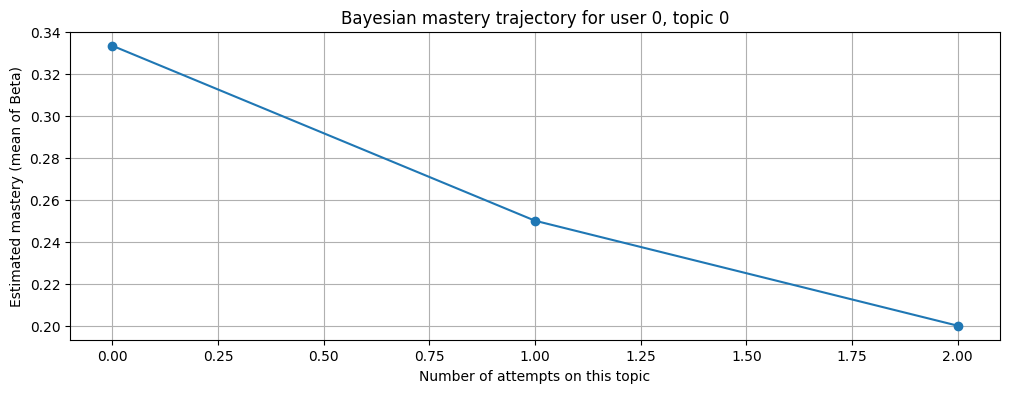

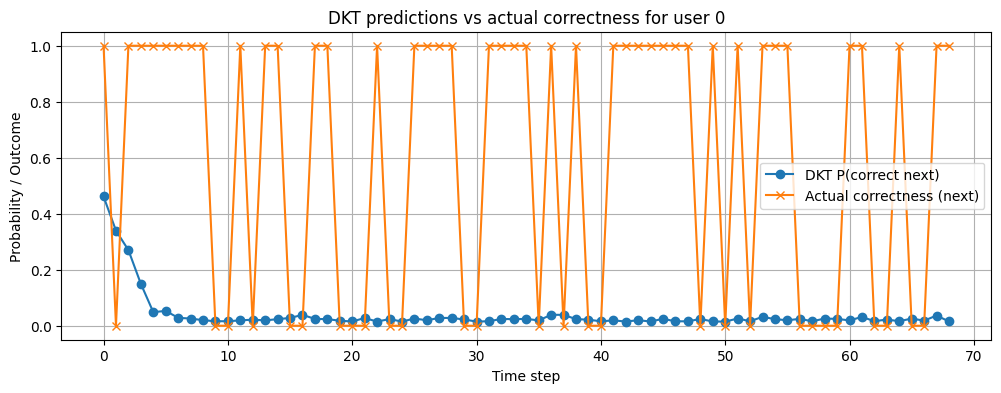

In [ ]:
test_user_id, test_seq = user_sequences[0]
print("\nInspecting user:", test_user_id, "sequence length:", len(test_seq))

# Build input sequence for DKT
inputs = []
topics = []
corrects = []
for i in range(len(test_seq) - 1):
    t, c = test_seq[i]
    inputs.append(encode_interaction(t, c, NUM_TOPICS))
    topics.append(t)
    corrects.append(c)

inputs_tensor = torch.tensor(inputs, dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    preds = model(inputs_tensor).cpu().numpy()[0]  # (seq_len-1, num_topics)

# For each step, get predicted P(correct) for the next topic
dkt_pred_next = []
true_next_correct = []
next_topics = []
for i in range(len(test_seq) - 1):
    next_topic, next_correct = test_seq[i + 1]
    p_next = preds[i, next_topic]
    dkt_pred_next.append(p_next)
    true_next_correct.append(next_correct)
    next_topics.append(next_topic)

# Bayesian mastery trajectory for one topic (e.g., topic 0)
topic_to_plot = 0
bayes_traj = bayesian_trajectories[test_user_id][topic_to_plot]

plt.figure(figsize=(12, 4))
plt.plot(bayes_traj, marker='o')
plt.title(f"Bayesian mastery trajectory for user {test_user_id}, topic {topic_to_plot}")
plt.xlabel("Number of attempts on this topic")
plt.ylabel("Estimated mastery (mean of Beta)")
plt.grid(True)
plt.show()

# Plot DKT predicted P(correct next) vs actual correctness
plt.figure(figsize=(12, 4))
plt.plot(dkt_pred_next, label="DKT P(correct next)", marker='o')
plt.plot(true_next_correct, label="Actual correctness (next)", marker='x')
plt.title(f"DKT predictions vs actual correctness for user {test_user_id}")
plt.xlabel("Time step")
plt.ylabel("Probability / Outcome")
plt.legend()
plt.grid(True)
plt.show()

#### 7. `Inspecting user: 0 sequence length: 70`

This means:

- We selected **user 0** for visualization.
- They have **70 interactions** in their sequence.

This is the sequence used to generate the two plots:
1. Bayesian mastery trajectory  
2. DKT predicted vs actual correctness  

---

#### Interpreting the Plots

Though we print them as images, here is what they mean.

---
> Plot 1 — Bayesian Mastery Trajectory

This plot shows how the student’s mastery of a single topic changes over time.

- **X‑axis:** number of attempts on that topic  
- **Y‑axis:** estimated mastery  
  $
  \hat{\theta} = \frac{\alpha}{\alpha + \beta}
  $

Interpretation:

- Upward curve → student is learning  
- Flat curve → inconsistent performance  
- Downward curve → student is struggling  
- Smoothness → Bayesian model is stable and interpretable  

This tells us **how well the student understands a specific topic**.

---

> Plot 2 — DKT Predicted vs Actual Correctness

This plot compares:

- **Blue line:** DKT’s predicted probability of correctness  
  $
  \hat{y}_{t,q_{t+1}}
  $
- **X markers:** actual correctness (0 or 1)

Interpretation:

- High predicted probability - model thinks student will answer correctly  
- Low predicted probability - model predicts a mistake  
- If the blue line follows the X’s - the model understands the student well  
- If they diverge - the student is unpredictable or inconsistent  

This tells us **how the student behaves over time**, not just what they know.



### TO Summarize -


In [ ]:
print("""
SUMMARY:
- Simulated users, topics, and interaction sequences.
- Tracked per-topic mastery with a Bayesian Beta model (alpha, beta updated per answer).
- Trained a DKT (LSTM) model to predict the probability of a correct next answer from the full history.
- Visualized:
    * Bayesian mastery trajectory for one topic.
    * DKT predicted P(correct next) vs actual correctness over time.
This is the core of a hybrid mastery system: Bayesian (online, interpretable) + DKT (sequence-aware, learned).
""")


SUMMARY:
- Simulated users, topics, and interaction sequences.
- Tracked per-topic mastery with a Bayesian Beta model (alpha, beta updated per answer).
- Trained a DKT (LSTM) model to predict the probability of a correct next answer from the full history.
- Visualized:
    * Bayesian mastery trajectory for one topic.
    * DKT predicted P(correct next) vs actual correctness over time.
This is the core of a hybrid mastery system: Bayesian (online, interpretable) + DKT (sequence-aware, learned).



# Understanding the Bayesian + DKT Mastery Model

- This note explains the full intuition and math behind the mastery model used in our adaptive learning system.
---

# 1. What We Are Trying to Model

A student interacts with topics over time:

- They answer some questions correctly.
- They answer some incorrectly.
- Their understanding changes as they learn.

We want to estimate:

1. **How well the student understands each topic right now**  
2. **How likely they are to get the next question correct**  
3. **How their knowledge evolves over time**

To do this, we use two models:

- **Bayesian Knowledge Tracking (BKT)** → interpretable, topic‑level mastery  
- **Deep Knowledge Tracing (DKT)** → neural network that learns patterns in behavior  

---

# 2. Bayesian Knowledge Tracking (BKT)

## 2.1 The core idea

Bayesian thinking says:

> “Start with a belief.  
> Update that belief every time you see new evidence.”

For each topic, we want a number between 0 and 1:

$\theta = \text{probability the student knows this topic}.$

But instead of storing just a single number, we store a **distribution** over possible values of $(\theta$).  
This lets us represent both:

- what we think the mastery is  
- how confident we are about that estimate  

The distribution we use is the **Beta distribution**.

---

## 2.2 Why the Beta distribution?

The Beta distribution is perfect because:

- it lives between 0 and 1  
- it updates cleanly when we observe correct/incorrect answers  

We write:

$
\theta \sim \mathrm{Beta}(\alpha, \beta).
$

- $(\alpha$) = “how many times we’ve seen evidence of correctness”  
- $(\beta$) = “how many times we’ve seen evidence of incorrectness”  

These do **not** literally count correct/incorrect answers — they are *soft counts* that grow with each observation.

---

## 2.3 Updating the belief

When the student answers a question:

- If correct → increase $(\alpha)$
- If incorrect → increase $(\beta)$

But we don’t increase them by exactly 1.  
We weight the update by:

- confidence  
- response speed  

So the update rule is:

$
\alpha \leftarrow \alpha + w_t \quad \text{if correct}\\
$

$
\beta \leftarrow \beta + w_t \quad \text{if incorrect}
$

where

$
w_t = c_t \cdot s_t.
$

This means:

- high‑confidence fast answers count more  
- low‑confidence slow answers count less  

---

## 2.4 The mastery estimate

After updating $(\alpha)$ and $(\beta)$, the estimated mastery is:

$
\hat{\theta} = \frac{\alpha}{\alpha + \beta}.
$

This is the **mean** of the Beta distribution.

- If $(\alpha)$ is much larger → mastery is high  
- If $(\beta)$ is much larger → mastery is low  

---

## 2.5 Uncertainty (variance)

The Beta distribution also gives us uncertainty:

$
\mathrm{Var}(\theta) =
\frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}.
$

- If the student has answered many questions → variance is small  
- If they’ve answered few → variance is large  

This is important because it tells us **how sure we are** about mastery.

---

## 2.6 Lower credible bound (LCB)

Sometimes we want a conservative estimate:

$
\mathrm{LCB}_{0.1} = \text{10th percentile of the Beta distribution}.
$

This answers:

> “What is the mastery level we are 90% sure the student has reached?”

This is useful for scheduling reviews or detecting weak topics.

---

# 3. Deep Knowledge Tracing (DKT)

## 3.1 Why Bayesian alone is not enough

Bayesian tracking assumes:

- topics are independent  
- the student’s behavior only depends on the last answer  
- slip/guess rates are fixed  

But real students:

- learn patterns  
- forget after topic switches  
- have long‑range dependencies  
- behave differently across topics  

DKT learns these patterns automatically.

---

## 3.2 Input encoding

Each interaction is:

$
(q_t, c_t)
$

where:

- $(q_t)$ = topic index  
- $(c_t)$ = correctness (0 or 1)

We convert this into a vector of length \(2K\):

$
\mathbf{x}_t \in \mathbb{R}^{2K}.
$

If topic $(i)$ was answered correctly:

$
x_{t,i} = 1.
$

If incorrectly:

$
x_{t,i+K} = 1.
$

Everything else is 0.

This tells the model:

- which topic was attempted  
- whether it was correct  

---

## 3.3 LSTM hidden state

The LSTM updates a hidden state:

$
\mathbf{h}_t = \mathrm{LSTM}(\mathbf{x}_t, \mathbf{h}_{t-1}).
$

This hidden state represents:

- memory of past answers  
- learning patterns  
- forgetting patterns  
- cross‑topic relationships  

---

## 3.4 Predicting the next answer

The model predicts correctness for **all topics** at the next step:

$
\hat{\mathbf{y}}_t = \sigma(W \mathbf{h}_t + b).
$

For topic $(i$):

$
\hat{y}_{t,i} = P(\text{correct on topic } i \mid \text{history}).
$

This is a probability between 0 and 1.

---

## 3.5 Loss function

We only care about the topic the student actually attempts next:

$
\mathcal{L}_t =
- \left[
c_{t+1} \log \hat{y}_{t,q_{t+1}}
+ (1 - c_{t+1}) \log (1 - \hat{y}_{t,q_{t+1}})
\right].
$

This is binary cross‑entropy.

The model learns by minimizing the total loss over all students and all time steps.

---

# 4. Hybrid Mastery Score

We combine Bayesian (stable, interpretable) and DKT (sequence‑aware):


$M_{u,k} = \lambda \cdot \hat{\theta}_{u,k}^{\mathrm{Bayes}} + (1 - \lambda)\cdot \hat{y}_{t,k}^{\mathrm{DKT}}$

- $(\hat{\theta}_{u,k}^{\mathrm{Bayes}})$ = topic‑level mastery  
- $(\hat{y}_{t,k}^{\mathrm{DKT}})$ = predicted correctness  
- $(\lambda)$ -> controls the balance  

This gives a mastery score that is:

- interpretable  
- personalized  
- predictive  
- stable  
- responsive to behavior  

---

# 5. How to Interpret the Outputs

## Bayesian curve
- Smooth  
- Shows mastery of a single topic  
- Goes up with correct answers  
- Goes down with incorrect answers  

## DKT curve
- Jagged  
- Predicts correctness at each time step  
- Learns patterns like forgetting, switching topics, streaks  

Together, they give a complete picture of:

- what the student knows  
- how they behave  
- how they learn over time  


### USER DEFINED DATASET -

In [ ]:
## UPLOADIG + PARSING USER DATASET -
import pandas as pd
from google.colab import files

print("Upload your dataset file (CSV, JSON, or TXT)...")
uploaded = files.upload()

# Get filename
filename = list(uploaded.keys())[0]
print("Loaded:", filename)
# Load based on extension
if filename.endswith(".csv"):
    df = pd.read_csv(filename)
elif filename.endswith(".json"):
    df = pd.read_json(filename)
elif filename.endswith(".txt"):
    df = pd.read_csv(filename, sep="\t")
else:
    raise ValueError("Unsupported file type. Please upload CSV, JSON, or TXT.")

print("Preview of uploaded dataset:")
display(df.head())
#------------------------------------------------------------------------------#
## VALIDATE REQUIRED COLUMNS
required_cols = {"user_id", "topic_id", "correct"}
missing = required_cols - set(df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Optional columns
has_conf = "confidence" in df.columns
has_time = "time_ms" in df.columns
#------------------------------------------------------------------------------#
#CONVERTING TO USER SEQUENCES COULMN -
user_sequences = []

for user_id, group in df.groupby("user_id"):
    seq = []
    for _, row in group.sort_values("topic_id").iterrows():
        topic = int(row["topic_id"])
        correct = int(row["correct"])
        seq.append((topic, correct))
    user_sequences.append((int(user_id), seq))

print(f"\nConverted dataset into {len(user_sequences)} user sequences.")
print("Example sequence:", user_sequences[0][:10])
#------------------------------------------------------------------------------#
# UPDATE NUM_USERS AND NUM_TOPICS
NUM_USERS = df["user_id"].nunique()
NUM_TOPICS = df["topic_id"].nunique()

print("\nDataset stats:")
print("Users:", NUM_USERS)
print("Topics:", NUM_TOPICS)